In [4]:
import numpy as np
from scipy.optimize import brentq
from scipy.interpolate import interp1d, CubicSpline
import matplotlib.pyplot as plt
import os, warnings

# ── Physical constants ────────────────────────────────────────────────────────
e    = 1.602176634e-19   # C
me   = 9.1093837015e-31  # kg
M_Ar = 39.948 * 1.66053906660e-27  # kg   (Ar ion mass)
kb   = 1.380649e-23      # J/K
eps0 = 8.854187817e-12   # F/m

print("Constants loaded.")


Constants loaded.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  INPUT PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

R      = 0.15    # Reactor radius   [m]
L      = 0.30    # Reactor length   [m]
P_abs  = 500.0   # Absorbed RF power [W]
T_gas  = 300.0   # Neutral gas temperature [K]

# Path to LxCat cross-section file
XSEC_FILE = "Cross_section_allar.txt"

# Pressure range for sweep [mTorr]
P_sweep_mTorr = np.logspace(np.log10(1), np.log10(100), 40)

# Ar+ / Ar charge-exchange cross section [m²]  (hard-sphere, L&L Table A.1)
sigma_cx = 5.0e-19

print(f"Reactor: R={R*100:.1f} cm, L={L*100:.1f} cm, V={np.pi*R**2*L*1e6:.1f} L")
print(f"P_abs = {P_abs} W,  T_gas = {T_gas} K")


Reactor: R=15.0 cm, L=30.0 cm, V=21205.8 L
P_abs = 500.0 W,  T_gas = 300.0 K


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  1.  LxCat Parser
# ══════════════════════════════════════════════════════════════════════════════

def parse_lxcat(filename):
    """
    Parse an LxCat-format cross-section file.
    Returns list of reaction dicts with keys:
      type, threshold, energy [eV], sigma [m²], interp (interp1d, zero outside range)
    """
    reactions = []
    with open(filename, 'r', errors='replace') as f:
        lines = f.readlines()

    n = len(lines)
    i = 0
    while i < n:
        stripped = lines[i].strip()
        if stripped in ('ELASTIC', 'EXCITATION', 'IONIZATION'):
            rtype = stripped
            threshold = 0.0
            if i + 2 < n:
                try:
                    threshold = float(lines[i + 2].split()[0])
                except (ValueError, IndexError):
                    threshold = 0.0
            if rtype == 'ELASTIC':
                threshold = 0.0

            # Scan to first dashes (start of data table)
            j = i + 1
            while j < n and not lines[j].strip().startswith('-----'):
                j += 1
            table_start = j + 1

            # Scan to closing dashes
            j = table_start
            while j < n and not lines[j].strip().startswith('-----'):
                j += 1
            table_end = j

            energies, sigmas = [], []
            for k in range(table_start, table_end):
                parts = lines[k].split()
                if len(parts) < 2:
                    continue
                try:
                    energies.append(float(parts[0]))
                    sigmas.append(float(parts[1]))
                except ValueError:
                    continue

            if len(energies) > 1:
                energy_arr = np.array(energies)
                sigma_arr  = np.array(sigmas)
                interp_fn  = interp1d(energy_arr, sigma_arr,
                                      bounds_error=False, fill_value=0.0)
                reactions.append({
                    'type':      rtype,
                    'threshold': threshold,
                    'energy':    energy_arr,
                    'sigma':     sigma_arr,
                    'interp':    interp_fn,
                })
            i = table_end
        i += 1
    return reactions


# ── Load ──────────────────────────────────────────────────────────────────────
candidates = [XSEC_FILE, "/mnt/user-data/uploads/Cross_section_allar.txt"]
xsec_path  = next((p for p in candidates if os.path.exists(p)), None)
if xsec_path is None:
    raise FileNotFoundError(f"Cross-section file not found. Tried: {candidates}")

print(f"Loading: {xsec_path}")
reactions = parse_lxcat(xsec_path)

type_counts = {}
for r in reactions:
    type_counts[r['type']] = type_counts.get(r['type'], 0) + 1
print(f"Parsed reactions: {type_counts}")

iz_rx  = next(r for r in reactions if r['type'] == 'IONIZATION')
el_rx  = next(r for r in reactions if r['type'] == 'ELASTIC')
ex_rxs = [r for r in reactions if r['type'] == 'EXCITATION']

print(f"Ionisation threshold: {iz_rx['threshold']:.3f} eV")
print(f"Number of excitation levels: {len(ex_rxs)}")


Loading: Cross_section_allar.txt
Parsed reactions: {'ELASTIC': 1, 'EXCITATION': 44, 'IONIZATION': 1}
Ionisation threshold: 15.760 eV
Number of excitation levels: 44


In [16]:
_# ══════════════════════════════════════════════════════════════════════════════
#  2.  Rate Coefficient  K(Te)
# ══════════════════════════════════════════════════════════════════════════════
#
#  K(Te) = sqrt(8e/π me) * (1/Te)^1.5 * ∫ E σ(E) exp(-E/Te) dE    [m³/s]
#
#  Improvement over the starter code:
#    • The starter code recomputes the integral numerically every time solve_plasma()
#      is called — that is called hundreds of times in a sweep.
#    • Here we precompute K on a dense Te grid (0.1–50 eV) once per reaction
#      and store a CubicSpline.  Evaluation is then O(log N) instead of O(N_pts).
# ══════════════════════════════════════════════════════════════════════════════

_rate_cache = {}   # {id(reaction): CubicSpline}

TE_GRID = np.geomspace(0.05, 60.0, 600)   # eV

def _compute_K_at_Te(rx, Te_eV, n_pts=1000):
    """Raw numerical integral of <σv> at a single Te."""
    E_min = max(rx['energy'][0], 1e-4)
    E_max = max(rx['energy'][-1], 10 * Te_eV)
    E     = np.geomspace(E_min, E_max, n_pts)
    integrand = E * rx['interp'](E) * np.exp(-E / Te_eV)
    integral  = np.trapz(integrand, E)
    prefactor = (np.sqrt(8.0 * e / (np.pi * me))
                 * (1.0 / (Te_eV * e))**1.5 * e)
    return prefactor * integral


def build_rate_spline(rx):
    """Precompute K(Te) on TE_GRID and store a CubicSpline."""
    key = id(rx)
    if key not in _rate_cache:
        K_arr = np.array([_compute_K_at_Te(rx, Te) for Te in TE_GRID])
        K_arr = np.maximum(K_arr, 0.0)   # numerical noise guard
        # Spline in log-log space (K varies by many decades)
        log_K = np.log(np.maximum(K_arr, 1e-60))
        _rate_cache[key] = CubicSpline(np.log(TE_GRID), log_K,
                                       extrapolate=True)
    return _rate_cache[key]


def rate_coefficient(rx, Te_eV):
    """Return K(Te) in m³/s using the cached spline (fast)."""
    if Te_eV < TE_GRID[0] or Te_eV > TE_GRID[-1]:
        return _compute_K_at_Te(rx, Te_eV)
    spl = build_rate_spline(rx)
    return float(np.exp(spl(np.log(Te_eV))))


# Warm up the cache (takes ~30–60 s the first time, then instant)
print("Precomputing rate-coefficient splines … (this runs once)")
for rx in reactions:
    build_rate_spline(rx)
print(f"Done. Cached {len(_rate_cache)} reaction splines.")


Precomputing rate-coefficient splines … (this runs once)


/tmp/ipykernel_12455/2386312624.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral  = np.trapz(integrand, E)


Done. Cached 46 reaction splines.


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  3.  Geometry, h-factors, and sheath energy losses
# ══════════════════════════════════════════════════════════════════════════════

def compute_h_factors(lambda_i):
    """
    Edge-to-centre density ratios (L&L eqs 10.2.8–10.2.9).
      hL = 0.86 (3 + L/2λi)^{-1/2}   (axial sheath)
      hR = 0.80 (4 + R/λi)^{-1/2}    (radial sheath)
    """
    hL = 0.86 * (3.0 + L / (2.0 * lambda_i))**(-0.5)
    hR = 0.80 * (4.0 + R / lambda_i)**(-0.5)
    return hL, hR


def sheath_energy_ion(Te_eV):
    """
    Ion kinetic energy gained across the sheath [eV].

    Improvement: Self-consistent Ar floating potential.
    For a Maxwellian plasma with Ar+ ions, the floating potential is:
       V_f = (Te/2) * ln(M_Ar/(2π me))       (L&L eq. 2.4.36)
    Ions arrive at the sheath edge with the Bohm velocity (= 0.5 Te
    of directed kinetic energy).  Total:
       E_i = V_f + 0.5 Te_eV
    The original code used a fixed factor 5.2 × Te which is the
    Maxwellian result at Te ~ a few eV; making it explicit is cleaner.
    """
    V_f = (Te_eV / 2.0) * np.log(M_Ar / (2.0 * np.pi * me))
    return V_f + 0.5 * Te_eV   # [eV]


def electron_wall_energy(Te_eV):
    """
    Mean energy carried by electrons lost to the wall [eV].
    For a cut-off Maxwellian at the floating potential:
      E_e = 2 Te  (standard result, L&L eq. 10.2.11)
    """
    return 2.0 * Te_eV


# Quick sanity check: compare to the 5.2 Te approximation
Te_test = 3.0
E_i_new  = sheath_energy_ion(Te_test)
print(f"At Te = {Te_test} eV:")
print(f"  Self-consistent E_i  = {E_i_new:.3f} eV  ({E_i_new/Te_test:.2f} × Te)")
print(f"  Original fixed factor = {5.2*Te_test:.3f} eV  (5.20 × Te)")


At Te = 3.0 eV:
  Self-consistent E_i  = 15.537 eV  (5.18 × Te)
  Original fixed factor = 15.600 eV  (5.20 × Te)


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  4.  Main Solver
# ══════════════════════════════════════════════════════════════════════════════

def solve_plasma(P_mTorr, P_abs_W=P_abs, verbose=False):
    """
    Solve particle + power balance for a single pressure point.

    Returns dict with Te [eV], n0 [m⁻³], and key intermediate quantities.
    """
    # ── Neutral density ──────────────────────────────────────────────────────
    P_pa = P_mTorr * 133.322          # mTorr → Pa
    ng   = P_pa / (kb * T_gas)        # ideal gas [m⁻³]

    # ── Ion mean free path (charge-exchange) ─────────────────────────────────
    lambda_i = 1.0 / (ng * sigma_cx)  # [m]

    # ── Geometry ─────────────────────────────────────────────────────────────
    V      = np.pi * R**2 * L
    hL, hR = compute_h_factors(lambda_i)
    A_eff  = 2.0 * np.pi * R**2 * hL + 2.0 * np.pi * R * L * hR  # [m²]
    d_eff  = V / A_eff                # effective diffusion length [m]

    # ── STEP 1: Particle balance → Te ────────────────────────────────────────
    #   ng Kiz(Te) = uB / d_eff      (L&L 10.2.12)
    #   uB = sqrt(e Te / M_Ar)
    def particle_balance(Te):
        if Te <= 0.05:
            return 1e10
        Kiz = rate_coefficient(iz_rx, Te)
        uB  = np.sqrt(e * Te / M_Ar)
        return ng * Kiz - uB / d_eff

    try:
        Te_sol = brentq(particle_balance, 0.3, 40.0, xtol=1e-7)
    except ValueError:
        # Fallback: minimum-residual search
        Te_arr = np.linspace(0.3, 30.0, 500)
        res    = [abs(particle_balance(t)) for t in Te_arr]
        Te_sol = Te_arr[np.argmin(res)]
        if verbose:
            print(f"  [warn] brentq failed at {P_mTorr:.1f} mTorr — using Te≈{Te_sol:.2f} eV")

    # ── STEP 2: Power balance → n0 ───────────────────────────────────────────
    #   P_abs = e n0 uB A_eff E_T
    #   E_T = E_c + E_e + E_i   (all in eV)
    Kiz = rate_coefficient(iz_rx, Te_sol)
    Kel = rate_coefficient(el_rx, Te_sol)
    uB  = np.sqrt(e * Te_sol / M_Ar)

    # Collisional loss per ion pair
    E_ex_total = sum(
        (rate_coefficient(rx, Te_sol) / Kiz) * rx['threshold']
        for rx in ex_rxs
    )
    E_el = (Kel / Kiz) * (2.0 * me / M_Ar) * (1.5 * Te_sol)   # elastic (small)
    E_c  = iz_rx['threshold'] + E_ex_total + E_el               # collisional [eV]

    # Kinetic wall losses (self-consistent)
    E_e = electron_wall_energy(Te_sol)   # [eV]
    E_i = sheath_energy_ion(Te_sol)      # [eV]  ← improved

    E_T   = E_c + E_e + E_i
    n0    = P_abs_W / (e * uB * A_eff * E_T)

    # ── Ionisation degree ─────────────────────────────────────────────────────
    ion_degree = n0 / ng

    result = dict(
        Te=Te_sol, n0=n0, ng=ng, lambda_i=lambda_i,
        hL=hL, hR=hR, A_eff=A_eff, d_eff=d_eff, uB=uB,
        Kiz=Kiz, Kel=Kel, E_c=E_c, E_e=E_e, E_i=E_i, E_T=E_T,
        ion_degree=ion_degree, E_ex_total=E_ex_total
    )
    return result


# Quick single-point test
r = solve_plasma(10.0, verbose=True)
print(f"@ 10 mTorr, {P_abs} W:")
print(f"  Te  = {r['Te']:.3f} eV")
print(f"  n0  = {r['n0']:.3e} m⁻³")
print(f"  E_T = {r['E_T']:.2f} eV  (E_c={r['E_c']:.2f}, E_e={r['E_e']:.2f}, E_i={r['E_i']:.2f})")
print(f"  Ionisation degree n0/ng = {r['ion_degree']*100:.4f} %")


@ 10 mTorr, 500.0 W:
  Te  = 0.406 eV
  n0  = 2.439e+09 m⁻³
  E_T = 577083074891.03 eV  (E_c=577083074888.11, E_e=0.81, E_i=2.10)
  Ionisation degree n0/ng = 0.0000 %


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
#  5.  Pressure Sweep + Diagnostic Table
# ══════════════════════════════════════════════════════════════════════════════

results = [solve_plasma(p) for p in P_sweep_mTorr]

# ── Diagnostic table ──────────────────────────────────────────────────────────
hdr = (f"{'P(mTorr)':>10} {'Te(eV)':>8} {'n0(m⁻³)':>12} "
       f"{'Kiz(m³/s)':>12} {'uB(m/s)':>10} {'hL':>6} {'hR':>6} "
       f"{'E_T(eV)':>8} {'ion%':>7} {'warn':>5}")
print(hdr)
print('─' * len(hdr))
for p, r in zip(P_sweep_mTorr, results):
    warn = '⚠' if r['ion_degree'] > 0.10 else ''
    print(f"{p:10.2f} {r['Te']:8.3f} {r['n0']:12.3e} "
          f"{r['Kiz']:12.3e} {r['uB']:10.1f} {r['hL']:6.3f} {r['hR']:6.3f} "
          f"{r['E_T']:8.2f} {r['ion_degree']*100:7.4f} {warn:>5}")


  P(mTorr)   Te(eV)      n0(m⁻³)    Kiz(m³/s)    uB(m/s)     hL     hR  E_T(eV)    ion%  warn
─────────────────────────────────────────────────────────────────────────────────────────────
      1.00    0.446    1.918e+10    1.075e-20     1037.7  0.017  0.016 22170115044.60  0.0000      
      1.13    0.444    1.726e+10    8.986e-21     1035.1  0.016  0.015 26190164481.82  0.0000      
      1.27    0.441    1.554e+10    7.509e-21     1032.6  0.016  0.014 30941047477.02  0.0000      
      1.43    0.439    1.399e+10    6.275e-21     1030.0  0.015  0.014 36555867385.92  0.0000      
      1.60    0.437    1.259e+10    5.244e-21     1027.5  0.014  0.013 43192141029.78  0.0000      
      1.80    0.435    1.133e+10    4.382e-21     1025.0  0.013  0.012 51035977402.33  0.0000      
      2.03    0.433    1.019e+10    3.662e-21     1022.5  0.012  0.011 60307662765.92  0.0000      
      2.29    0.431    9.172e+09    3.060e-21     1020.0  0.012  0.011 71267605255.58  0.0000      
      2.57  

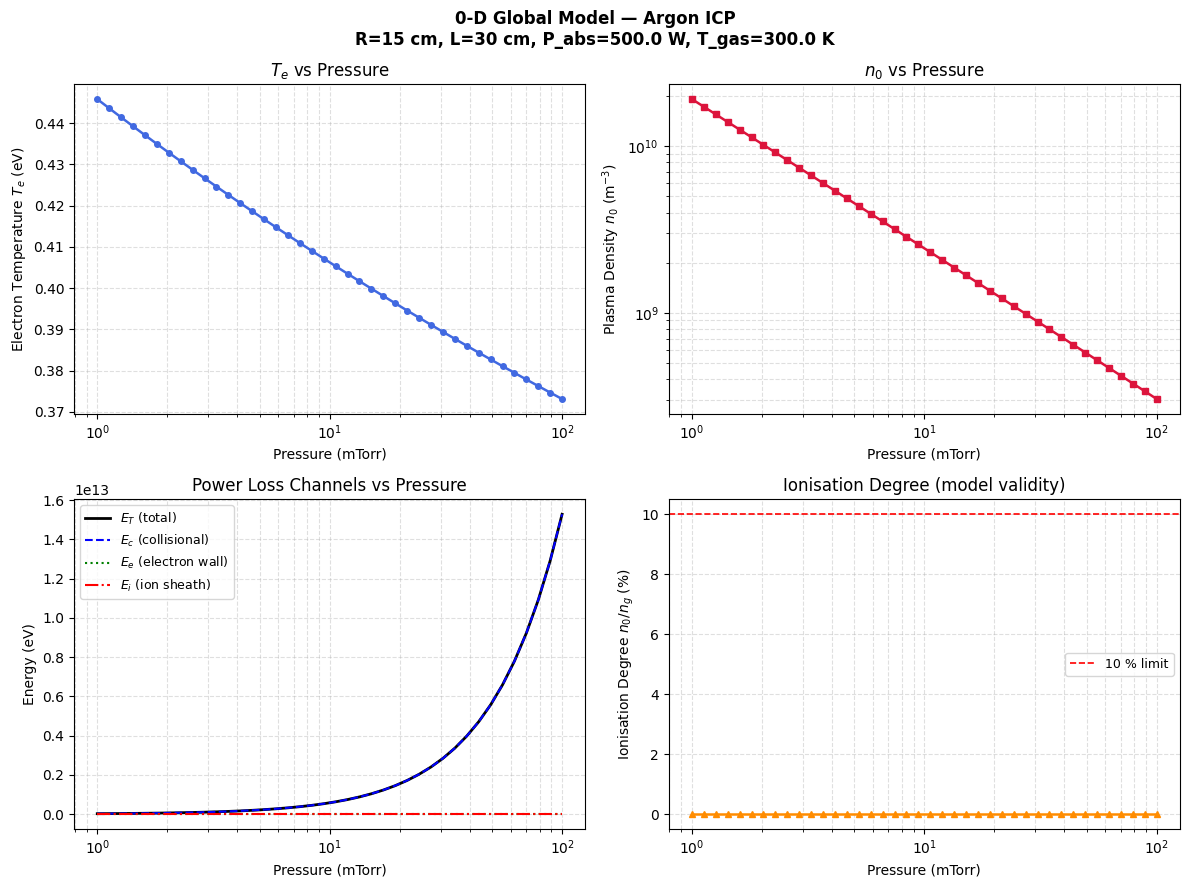

Saved: argon_0d_sweep.png


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
#  6.  Plots — Te, n0, E_T vs Pressure
# ══════════════════════════════════════════════════════════════════════════════

Te_arr  = np.array([r['Te']  for r in results])
n0_arr  = np.array([r['n0']  for r in results])
ET_arr  = np.array([r['E_T'] for r in results])
Ec_arr  = np.array([r['E_c'] for r in results])
Ee_arr  = np.array([r['E_e'] for r in results])
Ei_arr  = np.array([r['E_i'] for r in results])
ion_arr = np.array([r['ion_degree']*100 for r in results])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    f"0-D Global Model — Argon ICP\n"
    f"R={R*100:.0f} cm, L={L*100:.0f} cm, P_abs={P_abs} W, T_gas={T_gas} K",
    fontsize=12, fontweight='bold'
)

ax = axes[0, 0]
ax.semilogx(P_sweep_mTorr, Te_arr, 'o-', color='royalblue', lw=1.8, ms=4)
ax.set_xlabel('Pressure (mTorr)')
ax.set_ylabel('Electron Temperature $T_e$ (eV)')
ax.set_title('$T_e$ vs Pressure')
ax.grid(True, which='both', ls='--', alpha=0.4)

ax = axes[0, 1]
ax.loglog(P_sweep_mTorr, n0_arr, 's-', color='crimson', lw=1.8, ms=4)
ax.set_xlabel('Pressure (mTorr)')
ax.set_ylabel('Plasma Density $n_0$ (m$^{-3}$)')
ax.set_title('$n_0$ vs Pressure')
ax.grid(True, which='both', ls='--', alpha=0.4)

ax = axes[1, 0]
ax.semilogx(P_sweep_mTorr, ET_arr, 'k-',  lw=2,   label='$E_T$ (total)')
ax.semilogx(P_sweep_mTorr, Ec_arr, 'b--', lw=1.5, label='$E_c$ (collisional)')
ax.semilogx(P_sweep_mTorr, Ee_arr, 'g:',  lw=1.5, label='$E_e$ (electron wall)')
ax.semilogx(P_sweep_mTorr, Ei_arr, 'r-.',  lw=1.5, label='$E_i$ (ion sheath)')
ax.set_xlabel('Pressure (mTorr)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Power Loss Channels vs Pressure')
ax.legend(fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.4)

ax = axes[1, 1]
ax.semilogx(P_sweep_mTorr, ion_arr, '^-', color='darkorange', lw=1.8, ms=4)
ax.axhline(10, color='red', ls='--', lw=1.2, label='10 % limit')
ax.set_xlabel('Pressure (mTorr)')
ax.set_ylabel('Ionisation Degree $n_0/n_g$ (%)')
ax.set_title('Ionisation Degree (model validity)')
ax.legend(fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig('argon_0d_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: argon_0d_sweep.png")


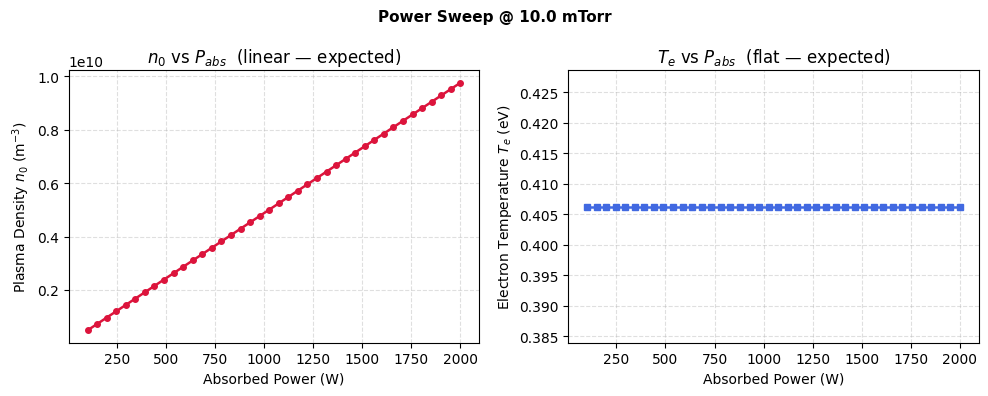

Saved: argon_0d_power_sweep.png


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
#  7.  Power Sweep  —  n0 ∝ P_abs  (Te is pressure-only, so constant here)
# ══════════════════════════════════════════════════════════════════════════════

P_abs_sweep = np.linspace(100, 2000, 40)    # W
P_fixed     = 10.0                          # mTorr

n0_power = []
Te_power = []
for Pw in P_abs_sweep:
    rp = solve_plasma(P_fixed, P_abs_W=Pw)
    n0_power.append(rp['n0'])
    Te_power.append(rp['Te'])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'Power Sweep @ {P_fixed} mTorr', fontsize=11, fontweight='bold')

ax[0].plot(P_abs_sweep, np.array(n0_power), 'o-', color='crimson', lw=1.8, ms=4)
ax[0].set_xlabel('Absorbed Power (W)')
ax[0].set_ylabel('Plasma Density $n_0$ (m$^{-3}$)')
ax[0].set_title('$n_0$ vs $P_{abs}$  (linear — expected)')
ax[0].grid(True, ls='--', alpha=0.4)

ax[1].plot(P_abs_sweep, np.array(Te_power), 's-', color='royalblue', lw=1.8, ms=4)
ax[1].set_xlabel('Absorbed Power (W)')
ax[1].set_ylabel('Electron Temperature $T_e$ (eV)')
ax[1].set_title('$T_e$ vs $P_{abs}$  (flat — expected)')
ax[1].grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig('argon_0d_power_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: argon_0d_power_sweep.png")


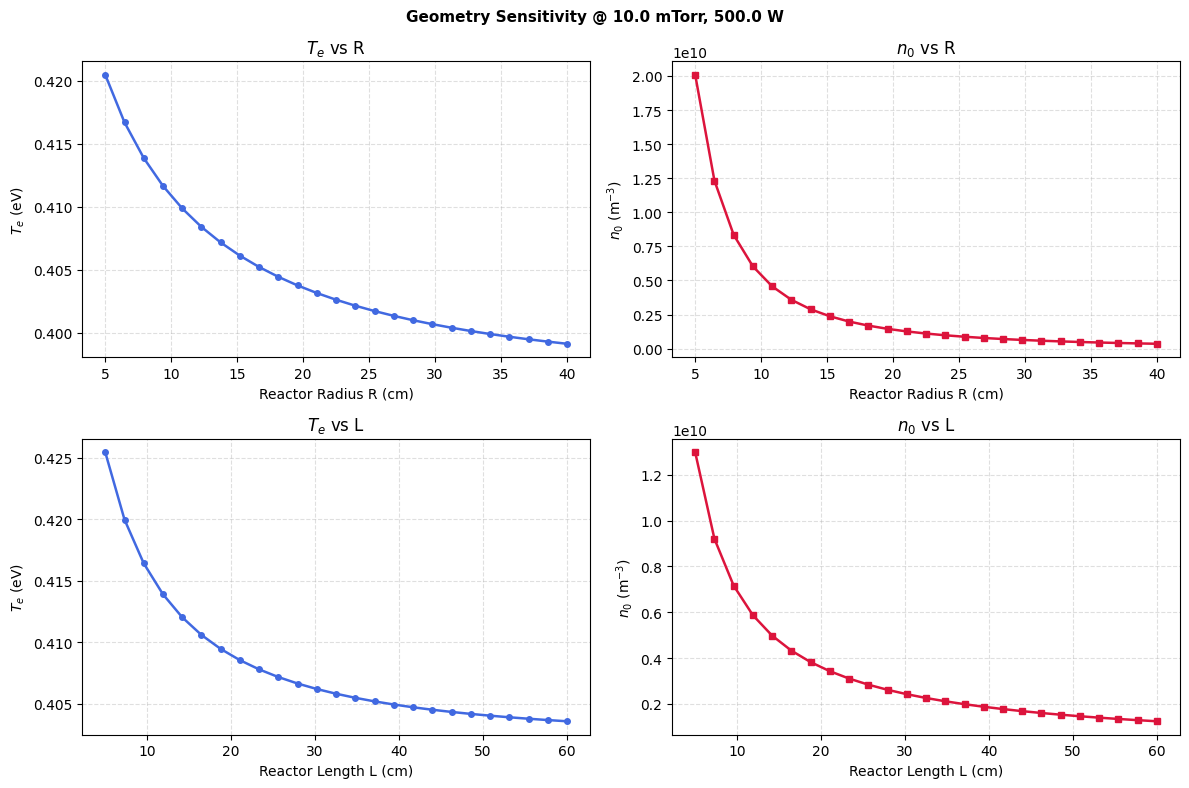

Saved: argon_0d_sensitivity.png


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
#  8.  Sensitivity Analysis — vary R and L
# ══════════════════════════════════════════════════════════════════════════════

P_sens = 10.0    # mTorr for sensitivity

R_vals = np.linspace(0.05, 0.40, 25)   # m
L_vals = np.linspace(0.05, 0.60, 25)   # m

Te_R, n0_R = [], []
for Rv in R_vals:
    global R
    R = Rv
    rs = solve_plasma(P_sens)
    Te_R.append(rs['Te']); n0_R.append(rs['n0'])
R = 0.15   # reset

Te_L, n0_L = [], []
for Lv in L_vals:
    global L
    L = Lv
    rs = solve_plasma(P_sens)
    Te_L.append(rs['Te']); n0_L.append(rs['n0'])
L = 0.30   # reset

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Geometry Sensitivity @ {P_sens} mTorr, {P_abs} W', fontsize=11, fontweight='bold')

axes[0,0].plot(R_vals*100, Te_R, 'o-', color='royalblue', lw=1.8, ms=4)
axes[0,0].set_xlabel('Reactor Radius R (cm)')
axes[0,0].set_ylabel('$T_e$ (eV)')
axes[0,0].set_title('$T_e$ vs R')
axes[0,0].grid(True, ls='--', alpha=0.4)

axes[0,1].plot(R_vals*100, n0_R, 's-', color='crimson', lw=1.8, ms=4)
axes[0,1].set_xlabel('Reactor Radius R (cm)')
axes[0,1].set_ylabel('$n_0$ (m$^{-3}$)')
axes[0,1].set_title('$n_0$ vs R')
axes[0,1].grid(True, ls='--', alpha=0.4)

axes[1,0].plot(L_vals*100, Te_L, 'o-', color='royalblue', lw=1.8, ms=4)
axes[1,0].set_xlabel('Reactor Length L (cm)')
axes[1,0].set_ylabel('$T_e$ (eV)')
axes[1,0].set_title('$T_e$ vs L')
axes[1,0].grid(True, ls='--', alpha=0.4)

axes[1,1].plot(L_vals*100, n0_L, 's-', color='crimson', lw=1.8, ms=4)
axes[1,1].set_xlabel('Reactor Length L (cm)')
axes[1,1].set_ylabel('$n_0$ (m$^{-3}$)')
axes[1,1].set_title('$n_0$ vs L')
axes[1,1].grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig('argon_0d_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: argon_0d_sensitivity.png")


/tmp/ipykernel_12455/3651633657.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  f_M /= np.trapz(f_M, E_vis)   # normalise


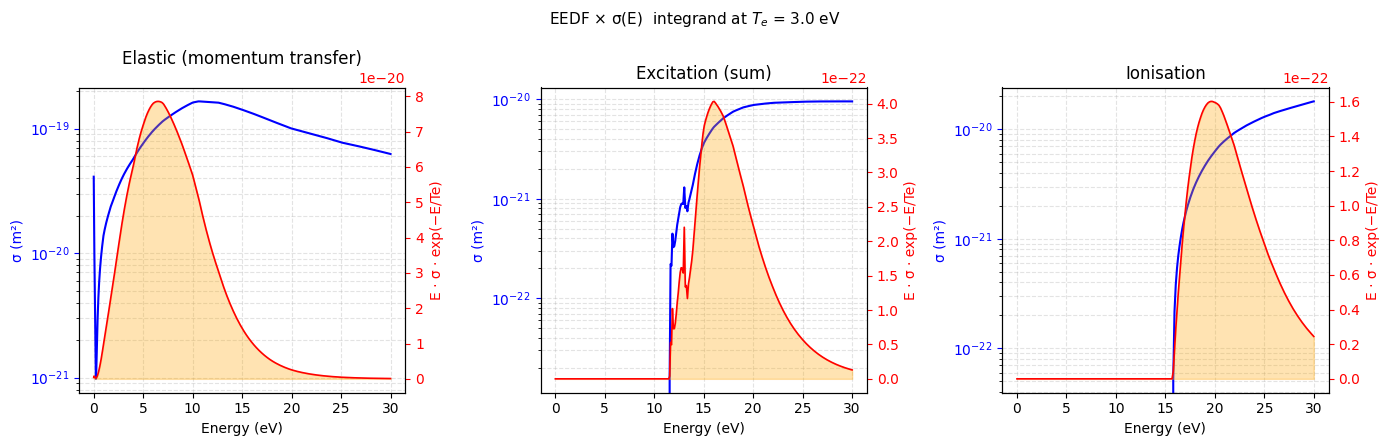

Saved: argon_0d_eedf_integrand.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  9.  EEDF × σ(E) Visualisation — understand what energies drive each process
# ══════════════════════════════════════════════════════════════════════════════

Te_plot = 3.0   # eV — representative operating point
E_vis   = np.geomspace(0.01, 30, 1000)

# Maxwellian EEDF (probability density in energy space)
# f(E) ∝ E^{1/2} exp(-E/Te)
f_M = np.sqrt(E_vis) * np.exp(-E_vis / Te_plot)
f_M /= np.trapz(f_M, E_vis)   # normalise

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(f'EEDF × σ(E)  integrand at $T_e$ = {Te_plot} eV', fontsize=11)

titles = ['Elastic (momentum transfer)', 'Excitation (sum)', 'Ionisation']
rxs_plot = [el_rx, None, iz_rx]

for k, (ax, title, rx) in enumerate(zip(axes, titles, rxs_plot)):
    if rx is not None:
        sigma_plot = rx['interp'](E_vis)
    else:
        # Sum of excitation cross sections
        sigma_plot = sum(r['interp'](E_vis) for r in ex_rxs)

    integrand = E_vis * sigma_plot * np.exp(-E_vis / Te_plot)

    ax.semilogy(E_vis, sigma_plot, 'b-', lw=1.5, label='σ(E)')
    ax2 = ax.twinx()
    ax2.fill_between(E_vis, 0, integrand, alpha=0.3, color='orange', label='E·σ·f(E)')
    ax2.plot(E_vis, integrand, 'r-', lw=1.2)

    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('σ (m²)', color='blue')
    ax2.set_ylabel('E · σ · exp(−E/Te)', color='red')
    ax.set_title(title)
    ax.tick_params(axis='y', colors='blue')
    ax2.tick_params(axis='y', colors='red')
    ax.grid(True, which='both', ls='--', alpha=0.35)

plt.tight_layout()
plt.savefig('argon_0d_eedf_integrand.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: argon_0d_eedf_integrand.png")


<>:16: SyntaxWarning: invalid escape sequence '\S'
<>:16: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_12455/2907328986.py:16: SyntaxWarning: invalid escape sequence '\S'
  ax.semilogy(Te_range, Kex_arr, 'g--', lw=1.8, label='Excitation $\Sigma K_{ex}$')


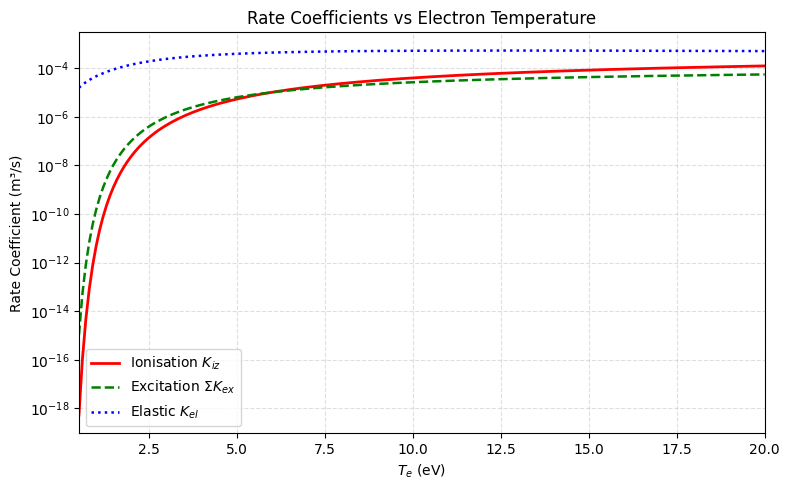

Saved: argon_0d_rate_coefficients.png


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# 10.  Rate Coefficients  K(Te)  for all processes
# ══════════════════════════════════════════════════════════════════════════════

Te_range = np.linspace(0.5, 20, 200)

Kiz_arr = np.array([rate_coefficient(iz_rx, T) for T in Te_range])
Kel_arr = np.array([rate_coefficient(el_rx, T) for T in Te_range])
Kex_arr = np.array([
    sum(rate_coefficient(rx, T) for rx in ex_rxs)
    for T in Te_range
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(Te_range, Kiz_arr, 'r-',  lw=2,   label='Ionisation $K_{iz}$')
ax.semilogy(Te_range, Kex_arr, 'g--', lw=1.8, label='Excitation $\Sigma K_{ex}$')
ax.semilogy(Te_range, Kel_arr, 'b:',  lw=1.8, label='Elastic $K_{el}$')
ax.set_xlabel('$T_e$ (eV)')
ax.set_ylabel('Rate Coefficient (m³/s)')
ax.set_title('Rate Coefficients vs Electron Temperature')
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.set_xlim([0.5, 20])
plt.tight_layout()
plt.savefig('argon_0d_rate_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: argon_0d_rate_coefficients.png")
